# Neuropixel Data Processing in BLAB 

In [1]:
# Imports
import os
from pathlib import Path
import spikeinterface.full as si
import scipy.io as sio
import matlab.engine
import matplotlib.pyplot as plt
import time, shutil
import spikeinterface.qualitymetrics as sqm

from neuroconv.utils.dict import load_dict_from_file
session_info = load_dict_from_file('./config/nwbsession_template.yaml')

In [2]:
# Functions all here 先运行所有函数
def _find_spikeglx_folder(data_path):
    """查找SpikeGLX文件夹"""
    # 查找以NPX开头的文件夹
    npx_folders = list(data_path.glob("NPX*"))
    if npx_folders:
        print('[INFO] use the fist NPX folder')
        return npx_folders[0]
    
    # 查找包含.bin和.meta文件的文件夹
    for folder in data_path.iterdir():
        if folder.is_dir():
            bin_files = list(folder.glob("*.bin"))
            meta_files = list(folder.glob("*.meta"))
            if bin_files and meta_files:
                return folder
    
    return None

## Step 0. Set session dir & Prepare Session Meta info

设置session数据目录，应包含 NPX* 文件夹 和 *.bhv2 

In [3]:
# 👇 change your session data dir 
session_path = Path(fr'E:\TripleN10k_Faladi_260325')

In [4]:
# read template
session_info

{'NWBFile': {'session_id': 'session250901',
  'session_description': 'Project ',
  'session_start_time': '1900-01-01T08:15:30-05:00',
  'lab': 'BLab@PKU',
  'institution': 'Peking University',
  'experimenter': ['Last, First', 'Last, First M.'],
  'experiment_description': 'None',
  'keywords': ['visual processing', 'neuropixels'],
  'notes': 'None',
  'related_publications': [''],
  'data_collection': 'situation of the experiment',
  'stimulus_notes': 'None'},
 'Subject': {'subject_id': 'MaoDan',
  'description': 'good monkey',
  'species': 'Macaca mulatta',
  'sex': 'M',
  'age': 'P4Y',
  'weight': '12.8kg'}}

In [5]:
# change the session content
session_target_area = 'MSB'
session_info['NWBFile']['session_id'] = 'session0325'
session_info['NWBFile']['experimenter'] = ['Gong, Zhengxin', 'Li, Yipeng', 'Zheng, Yuechenyang']
session_info['NWBFile']['session_description'] = 'TripleN 10k with test set'

session_info['Subject']['subject_id'] = 'Faladi'
session_info['Subject']['weight'] = '9kg'


## Step 1. Run kilosort

可以决定是否使用 motion_correction （类似fMRI，机械移动对于spikesorting结果也会造成明显的影响。同时，校正会显著地增加处理时长）

Reference Reading: https://spikeinterface.readthedocs.io/en/latest/modules/motion_correction.html 

In [6]:
use_motion_correction = True # 对于长时间 session 默认使用

In [6]:
# Read and prepare output folders
spikeglx_folder = _find_spikeglx_folder(session_path)

stream_names, stream_ids = si.get_neo_streams('spikeglx',spikeglx_folder)
print(stream_names)
out_path = session_path / 'processed'
out_path.mkdir(exist_ok=True)
mot_correct_path = out_path / 'folder_KS4' / 'motion'
preprocessed_path = out_path / 'SI' / 'preprocess'
sorting_path = out_path / 'SI' / 'KS4'
analyzer_path = out_path / 'SI' / 'analyzer'
report_path = out_path / 'SI' / 'report'

import yaml
info_yaml = out_path / 'session_info.yaml'
with open(info_yaml, 'w', encoding='utf-8') as f:
    yaml.dump(session_info, f, default_flow_style=False, allow_unicode=True, indent=4)

[INFO] use the fist NPX folder
['imec0.ap', 'nidq', 'imec0.lf', 'imec0.ap-SYNC', 'imec0.lf-SYNC']


### kilosort等处理在 Analysis_dredge.ipynb 中完成。如下板块的现已弃用：

In [8]:
# Preprocessing
raw_rec = si.read_spikeglx(spikeglx_folder, stream_name='imec0.ap', load_sync_channel=False)
raw_rec.get_probe().to_dataframe()
rec3 = si.highpass_filter(recording=raw_rec, freq_min=300.)
bad_channel_ids, channel_labels = si.detect_bad_channels(rec3)
rec3 = rec3.remove_channels(bad_channel_ids)
rec3 = si.phase_shift(rec3)
rec3 = si.common_reference(rec3, operator="median", reference="global")

c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\spikeinterface\preprocessing\detect_bad_channels.py:418: RuntimeWarning: invalid value encountered in divide
  xcorr = np.sum(raw * ref[:, np.newaxis], axis=0) / np.sum(ref**2)


In [10]:
# motion correction
if use_motion_correction:
    job_kwargs = dict(n_jobs=20, chunk_duration="3s", progress_bar=True) # 4 is ok?
    preset = 'dredge'
    print("Computing with", preset)
    folder = mot_correct_path / preset
    if folder.exists():
        shutil.rmtree(folder)
    corrected_rec, motion_info = si.correct_motion(recording=rec3, preset=preset, folder=str(folder), output_motion_info=True, **job_kwargs)
    motion_info = si.load_motion_info(folder)
    fig = plt.figure(figsize=(14, 8))
    si.plot_motion_info(motion_info, rec3,figure=fig,color_amplitude=True,amplitude_cmap="inferno",scatter_decimate=10,)

Computing with dredge


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect and localize (workers: 20 processes):   0%|          | 0/6823 [00:00<?, ?it/s]

RuntimeError: Motion estimation failed. Error given: CUDA call failed lazily at initialization with error: module 'torch' has no attribute 'version'

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "c:\Users\Gong\miniconda3\envs\dataprocess\Lib\asyncio\base_events.py", line 608, in run_forever
    self._run_once()
 

In [ ]:
# save the preprocessed
job_kwargs = dict(n_jobs=16, chunk_duration='4s', progress_bar=True)
if use_motion_correction:
    preprocessed_rec = corrected_rec.save(
                    folder= str(preprocessed_path), 
                    format='zarr', 
                    # overwrite=True,
                    **job_kwargs
                )
else:
    corrected_rec = rec3
    preprocessed_rec = corrected_rec.save(
                    folder=str(preprocessed_path), 
                    format='zarr', 
                    # overwrite=True,
                    **job_kwargs
                )

write_zarr_recording 
engine=process - n_jobs=12 - samples_per_chunk=119,999 - chunk_memory=175.32 MiB - total_memory=2.05 GiB - chunk_duration=4.00s


write_zarr_recording (workers: 12 processes):   0%|          | 0/3178 [00:00<?, ?it/s]

In [ ]:
# kilosort 
zarr_preprocess_path = preprocessed_path.parent / preprocessed_path.name.replace('preprocess', 'preprocess.zarr')
preprocessed_rec = si.load(zarr_preprocess_path)
from spikeinterface.sorters import run_sorter
sorting_KS4 = run_sorter(
                    sorter_name="kilosort4", 
                    recording=preprocessed_rec, 
                    folder=str(sorting_path), 
                    nblocks=20,
                    n_jobs=12,
                    chunk_duration='4s'
                )

100%|██████████| 2/2 [09:14<00:00, 277.09s/it]


In [5]:
sorting_KS4 = si.load(sorting_path)

In [6]:
zarr_preprocess_path = preprocessed_path.parent / preprocessed_path.name.replace('preprocess', 'preprocess.zarr')
preprocessed_rec = si.load(zarr_preprocess_path)

In [8]:
# analyzer & report
analyzer = si.create_sorting_analyzer(sorting_KS4, preprocessed_rec, sparse=True, format="memory")
job_kwargs = dict(n_jobs=12, chunk_duration="2s", progress_bar=True)
analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500, **job_kwargs)
analyzer.compute("waveforms",  ms_before=1.5,ms_after=2., **job_kwargs)
analyzer.compute("templates", operators=["average", "median", "std"],**job_kwargs)
analyzer.compute("noise_levels", **job_kwargs)
analyzer.compute("correlograms", **job_kwargs)
analyzer.compute("unit_locations", **job_kwargs)
analyzer.compute("spike_amplitudes", **job_kwargs)
analyzer.compute("template_similarity", **job_kwargs)

import spikeinterface.qualitymetrics as sqm
qm_params = sqm.get_default_qm_params()
qm_params["isi_violation"]["min_isi_ms"] = 0.1
qm_params["presence_ratio"]["bin_duration_s"] = 10

analyzer.compute('quality_metrics',qm_params, **job_kwargs)

analyzer_saved = analyzer.save_as(folder=str(analyzer_path), format="binary_folder")
si.export_report(analyzer_saved, str(report_path), format='png')

estimate_sparsity (no parallelization):   0%|          | 0/12710 [00:00<?, ?it/s]

compute_waveforms (workers: 12 processes):   0%|          | 0/6355 [00:00<?, ?it/s]

noise_level (workers: 12 processes):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (workers: 12 processes):   0%|          | 0/6355 [00:00<?, ?it/s]

c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\spikeinterface\qualitymetrics\misc_metrics.py:1066: UserWarning: Some units have too few spikes : amplitude_cutoff is set to NaN
  warnings.warn(f"Some units have too few spikes : amplitude_cutoff is set to NaN")
c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\spikeinterface\qualitymetrics\misc_metrics.py:163: UserWarning: No bin is selected to test cutoff. Please increase low_quantile. Setting noise cutoff and ratio to NaN
  warnings.warn(


In [ ]:
# 清理内存
import gc
del preprocessed_rec, rec3, raw_rec, analyzer_saved, analyzer, sorting_KS4, 
gc.collect()

NameError: name 'preprocessed_rec' is not defined

## Step 2. Meta data check and alignment

In [7]:
from core.data_loader import DataLoader
from core.synchronizer import DataSynchronizer
# from core.spike_sorter import SpikeSorter
from core.quality_controller import QualityController

✅ ipywidgets available - interactive GUI ready


2026-03-29 21:20:46 - process_20260329_212026 - INFO - MATLAB引擎初始化成功
2026-03-29 21:20:46 - process_20260329_212026 - INFO - 开始步骤: load_spikeglx - 加载SpikeGLX神经数据和同步信号 (流: imec0.ap)
2026-03-29 21:20:46 - process_20260329_212026 - INFO - 找到SpikeGLX文件夹: E:\TripleN10k_Faladi_260325\NPX_FLD260325_exp2_g7
2026-03-29 21:20:49 - process_20260329_212026 - INFO - 成功加载nidq同步数据
2026-03-29 21:20:49 - process_20260329_212026 - INFO - 数字通道映射: {'sync': 0, 'trial_start': 3, 'stim_onset': 6}
2026-03-29 21:20:51 - process_20260329_212026 - INFO - 成功加载imec同步数据
2026-03-29 21:20:51 - process_20260329_212026 - INFO - 步骤完成: load_spikeglx (耗时: 0:00:04.439334) - 成功加载SpikeGLX数据和同步信号
2026-03-29 21:20:51 - process_20260329_212026 - INFO - 开始步骤: load_monkeylogic - 加载MonkeyLogic行为数据
2026-03-29 21:20:51 - process_20260329_212026 - INFO - 找到MonkeyLogic文件: E:\TripleN10k_Faladi_260325\260325_Faladi_nsd1w.bhv2
2026-03-29 21:20:51 - process_20260329_212026 - INFO - 成功从缓存加载数据: E:\TripleN10k_Faladi_260325\processed\ML_260325

0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:   11.3s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 249 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:  


⚙️ Computing quality metrics for 706 units...
   (Progress bar will appear below)


Computing bombcell quality metrics:   0%|          | 0/706 units


Saving GUI visualization data...
GUI visualization data saved to: E:\TripleN10k_Faladi_260325\processed\SI\bombcell\for_GUI\gui_data.pkl
   Generated spatial decay fits: 705/706 units
   Generated amplitude fits: 705/706 units

🏷️ Classifying units (good/MUA/noise/non-soma)...

Generating summary plots...


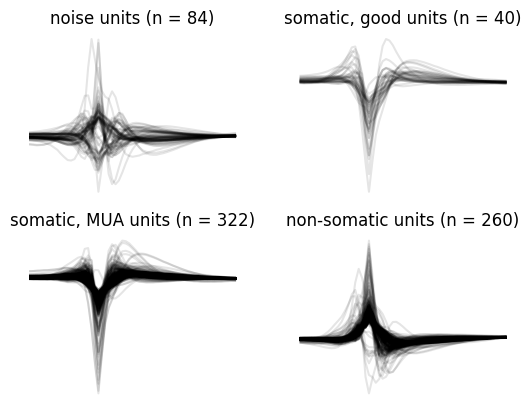

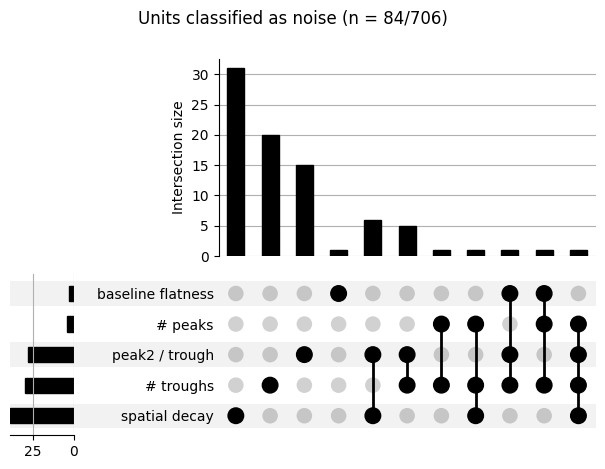

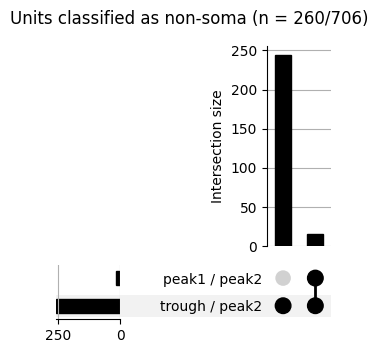

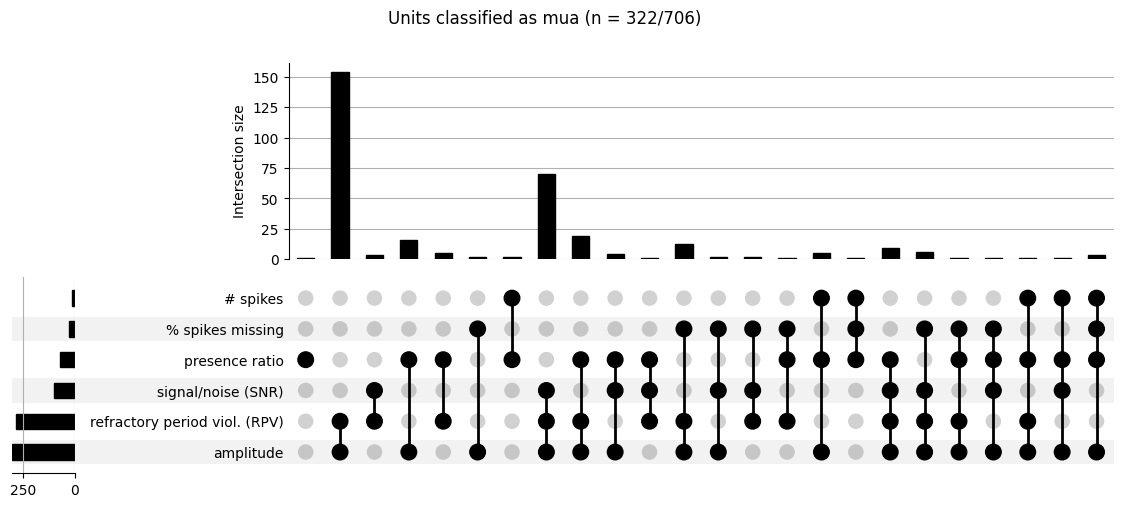

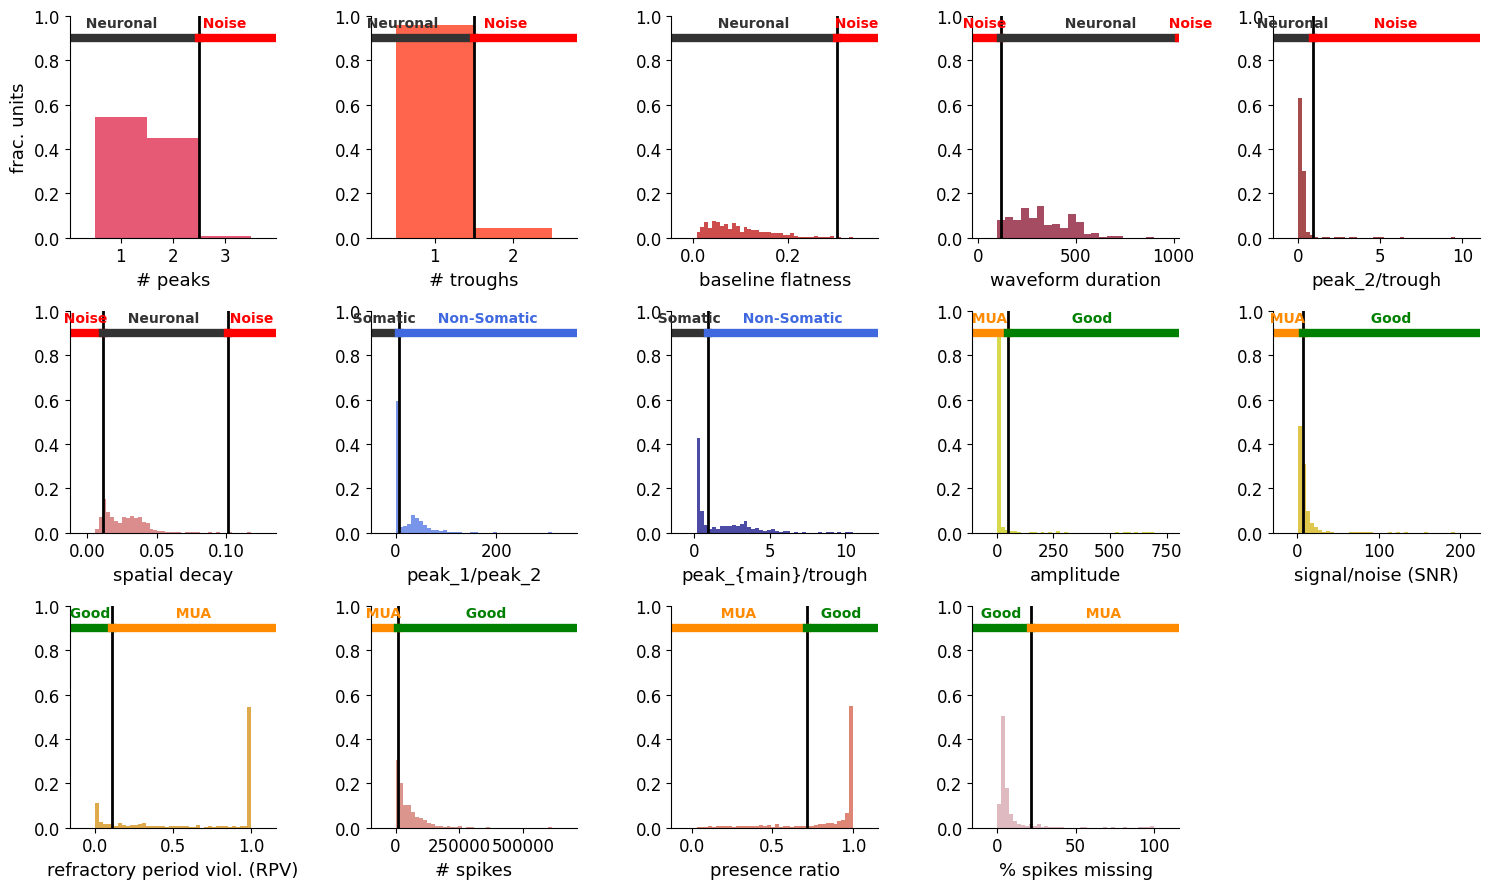


Saving results...
📁 Saving TSV files to Kilosort directory: E:\TripleN10k_Faladi_260325\processed\SI\KS4\sorter_output
All expected metrics were successfully saved.
2026-03-29 21:25:55 - process_20260329_212124 - INFO - Bombcell结果已保存到: E:\TripleN10k_Faladi_260325\processed\SI\bombcell\bombcell_results.json
2026-03-29 21:25:55 - process_20260329_212124 - INFO - 处理结果 (Bombcell质量控制结果):
  total_units: 706
  good_units: 40
  mua_units: 322
  no-somatic_units: 260
  noise_units: 84
  good_unit_ratio: 0.8810198300283286
  qMetric_summary: {'phy_clusterID': {'mean': 352.5, 'std': 203.80444057968904, 'median': 352.5}, 'nSpikes': {'mean': 50764.668555240794, 'std': 59587.85794994606, 'median': 29782.5}, 'nPeaks': {'mean': 1.4624113475177305, 'std': 0.5098378280738528, 'median': 1.0}, 'nTroughs': {'mean': 1.0425531914893618, 'std': 0.2018475102235136, 'median': 1.0}, 'waveformDuration_peakTrough': {'mean': 322.45862884160755, 'std': 138.00883092658515, 'median': 300.0}, 'spatialDecaySlope': {'me

f:\tools\ProcessPipeline\pyneuralpipe\core\quality_controller.py:231: RuntimeWarning: Mean of empty slice
  'mean': float(np.nanmean(values_array)),
c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
f:\tools\ProcessPipeline\pyneuralpipe\core\quality_controller.py:233: RuntimeWarning: All-NaN slice encountered
  'median': float(np.nanmedian(values_array))


In [9]:
%matplotlib inline
# step 1 读取采集数据
data_loader = DataLoader(session_path)
## 读取 spikeGLX 
data_loader.load_spikeglx()
neural_data = data_loader.get_spikeglx_data()
## 读取 MonkeyLogic
data_loader.load_monkeylogic()
# monkeylogic_data = data_loader.get_monkeylogic_data()
## 同步数据 与 元数据
sync_data = data_loader.get_sync_data()
metadata = data_loader.get_metadata()
print(sync_data.keys(), metadata.keys())
# step 2 数据同步校准
synchronizer = DataSynchronizer(data_loader)
synchronizer.process_full_synchronization()
export_data = synchronizer.get_export_data()
print(export_data.keys())
# step 3 quality check
processed_path = session_path / "processed"
ks_output_path = sorting_path / "sorter_output"
imec_path = spikeglx_folder / f"{spikeglx_folder.name}_imec0" 
quality_controller = QualityController(kilosort_output_path=ks_output_path, 
    imec_data_path=imec_path)
bc_params = quality_controller.setup_bombcell_params()
bombcell_results = quality_controller.run_quality_control()


In [12]:
export_data['session_info']

{'data_path': 'E:\\TripleN10k_JianJian260302',
 'exp_day': '260302',
 'exp_subject': 'JianJian',
 'dataset_path': 'D:\\img_vault\\nsd1w\\nsd1w.tsv',
 'dataset_name': 'nsd1w',
 'processing_timestamp': '2026-03-06T09:46:18.906029',
 'imgset_size': 10072,
 'valid_eye_count': 50989}

In [10]:
%reload_ext autoreload
%autoreload 2
from core.data_integrator import DataIntegrator
import sys
import importlib
core_data_module = sys.modules['core.data_integrator']
importlib.reload(core_data_module)
from core.data_integrator import DataIntegrator


output_folder = session_path / "processed" 
integrator = DataIntegrator(
    data_path=session_path,
    info_yaml=info_yaml, # step0 处准备
    output_folder=output_folder,
    target_area=session_target_area # step0 处准备
)

integrator.run_full_pipeline()

2026-03-29 21:25:56 - DataIntegrator - INFO - 找到 SpikeGLX 数据: E:\TripleN10k_Faladi_260325\NPX_FLD260325_exp2_g7
2026-03-29 21:25:56 - DataIntegrator - INFO - 找到 META 文件: E:\TripleN10k_Faladi_260325\processed\META_TripleN10k_Faladi_260325.h5
2026-03-29 21:25:56 - DataIntegrator - INFO - 开始完整的数据整合流程
2026-03-29 21:25:56 - DataIntegrator - INFO - ============================================================
2026-03-29 21:25:56 - DataIntegrator - INFO - ============================================================
2026-03-29 21:25:56 - DataIntegrator - INFO - Step 1: 转换原始数据到 NWB 文件
2026-03-29 21:25:56 - DataIntegrator - INFO - ============================================================
2026-03-29 21:25:56 - DataIntegrator - INFO - 创建 SpikeGLX 转换器...
2026-03-29 21:26:01 - DataIntegrator - INFO - 准备元数据...
2026-03-29 21:26:01 - DataIntegrator - INFO - 配置后端参数...
2026-03-29 21:26:07 - DataIntegrator - INFO - 开始转换，输出文件: E:\TripleN10k_Faladi_260325\processed\NWBFile_260325_Faladi_nsd1w_MSB.nwb
Meta

  0%|          | 0/463 [00:00<?, ?it/s]c:\Users\Gong\miniconda3\envs\dataprocess\Lib\site-packages\hdmf\container.py:889: UserWarning: 32001 compression may not be available on all installations of HDF5. Use of gzip is recommended to ensure portability of the generated HDF5 files.
  self.fields[dataset_name] = data_io_class(data=data, **data_io_kwargs)
                                                   
100%|██████████| 463/463 [1:41:28<00:00, 13.08s/it]

                                                   
100%|██████████| 463/463 [1:47:10<00:00, 13.08s/it]



2026-03-29 23:13:25 - DataIntegrator - INFO - ✓ Step 1 完成: 原始数据已转换
2026-03-29 23:13:25 - DataIntegrator - INFO - ============================================================
2026-03-29 23:13:25 - DataIntegrator - INFO - Step 2: 添加 Kilosort 排序结果
2026-03-29 23:13:25 - DataIntegrator - INFO - ============================================================
2026-03-29 23:13:25 - DataIntegrator - INFO - 从 E:\TripleN10k_Faladi_260325\processed\SI\KS4\sorter_output 添加 Kilosort 结果...
2026-03-29 23:14:55 - DataIntegrator - INFO - ✓ Step 2 完成: Kilosort 结果已添加
2026-03-29 23:14:55 - DataIntegrator - INFO - ============================================================
2026-03-29 23:14:55 - DataIntegrator - INFO - Step 3: 添加行为数据
2026-03-29 23:14:55 - DataIntegrator - INFO - ============================================================
2026-03-29 23:14:55 - DataIntegrator - INFO - 从 E:\TripleN10k_Faladi_260325\processed\META_TripleN10k_Faladi_260325.h5 加载行为数据...
2026-03-29 23:14:55 - DataIntegrator - INFO

2026-03-29 23:36:13 - DataIntegrator - INFO - 添加了 54041 个 trials
2026-03-29 23:36:13 - DataIntegrator - INFO - 添加了眼动追踪数据 (8106150 个时间点)


2026-03-29 23:36:14 - DataIntegrator - INFO - ✓ Step 3 完成: 行为数据已添加
2026-03-29 23:36:14 - DataIntegrator - INFO - ============================================================
2026-03-29 23:36:14 - DataIntegrator - INFO - Step 4: 添加自定义 units
2026-03-29 23:36:14 - DataIntegrator - INFO - ============================================================
2026-03-29 23:36:14 - DataIntegrator - INFO - 读取现有的 units 和 trials...
2026-03-29 23:36:14 - DataIntegrator - INFO - 找到 706 个 units
2026-03-29 23:36:14 - DataIntegrator - INFO - 加载 Bombcell 数据: E:\TripleN10k_Faladi_260325\processed\SI\bombcell
2026-03-29 23:36:14 - DataIntegrator - INFO - 删除 3 个全为 NaN 的列
2026-03-29 23:36:15 - DataIntegrator - INFO - 添加了 6 个自定义列 + Bombcell 质量指标列





































































































































































































































































































































































































































































































































































































































































































































添加 units: 100%|██████████| 706/706 [41:44<00:00,  3.55s/it]

2026-03-30 00:18:00 - DataIntegrator - INFO - 添加了 618 个 units，过滤了 88 个 units


2026-03-30 00:19:16 - DataIntegrator - INFO - ✓ Step 4 完成: 自定义 units 已添加
2026-03-30 00:19:16 - DataIntegrator - INFO - ============================================================
2026-03-30 00:19:16 - DataIntegrator - INFO - ✓ 数据整合完成！
2026-03-30 00:19:16 - DataIntegrator - INFO - 输出文件: E:\TripleN10k_Faladi_260325\processed\NWBFile_260325_Faladi_nsd1w_MSB.nwb
2026-03-30 00:19:16 - DataIntegrator - INFO - ============================================================


WindowsPath('E:/TripleN10k_Faladi_260325/processed/NWBFile_260325_Faladi_nsd1w_MSB.nwb')

In [15]:
integrator.config['stimulus']['add_to_nwb']

False

In [21]:
import gc
del  bc_params, bombcell_results #integrator
gc.collect()

45

# Post-process For tripleN10k

In [1]:
from pynwb import NWBHDF5IO
from pathlib import Path
import pandas as pd
import sys
import importlib
import numpy as np
from analysis_codes import spike_times_to_raster, raster_to_psth
from analysis_codes import save_raster_h5, load_raster_h5_fast, load_raster_lazy
from analysis_codes import split_half_reliability_fast, split_half_reliability_parallel

In [ ]:
data_dir = Path(fr'E:\TripleN10k_JianJian260302\processed')
sesname = '260302_JianJian_nsd1w_AL-ASB'
session_filepath = data_dir / f'NWBFile_{sesname}.nwb'
# 1. 打开 NWB 文件
with NWBHDF5IO(session_filepath, 'r') as io:
  # 2. 读取文件内容
  nwbfile = io.read()
  # 3. 获取文件信息
  #   print(nwbfile)
  trial_df = nwbfile.trials.to_dataframe()
  unit_df = nwbfile.units.to_dataframe()
  # print(nwbfile.units.colnames)
trial_raster = spike_times_to_raster(unit_df, trial_df, pre_onset=50, post_onset=300, n_jobs=1)
raster_meta = dict(pre_onset=50, post_onset=300)
raster_file = data_dir / f'TrialRaster_{sesname}.h5'
save_raster_h5(str(raster_file), trial_raster, metadata=raster_meta)

使用 memmap (14.5 GB) -> C:\Users\Gong\AppData\Local\Temp\_raster_tmp_47032.dat


Processing chunks: 100%|█████████████████████████████████████████| 18/18 [03:22<00:00, 11.23s/chunk]


{'filepath': 'E:\\TripleN10k_JianJian260302\\processed\\TrialRaster_260302_JianJian_nsd1w.h5',
 'storage_format': 'sparse',
 'original_size_mb': 14891.988039016724,
 'file_size_mb': 108.77465057373047,
 'compression_ratio': 136.9067881208455,
 'sparsity': np.float64(0.9966368765411988),
 'shape': (875, 50989, 350)}

In [3]:
unit_prop = unit_df[['ks_id', 'unitpos', 'unittype', 'unittype_string']]
unit_prop.to_csv(data_dir / f'UnitProp_{sesname}.csv')
trial_df.to_csv(data_dir / f'TrialRecord_{sesname}.csv')

In [ ]:
tpndata_dir = Path(fr'F:\#TripleN10k\data')

ses_name = '260302_JianJian_nsd1w_AL-ASB' #'251024_FanFan_nsd1w' #'250416_JianJian_nsd1w' # 
ses_trialrecord = pd.read_csv(tpndata_dir / fr'TrialRecord_{ses_name}.csv')
test_indices = np.load(fr'F:\#TripleN10k\sequence_via_features\tpn10k_dinov2_test_indices.npy') + 1
is_test = np.isin(ses_trialrecord['stim_index'].values, test_indices)
ses_trialrecord['is_test'] = is_test
ses_trialrecord.to_csv(tpndata_dir / fr'TrialRecord_{ses_name}.csv', index=False)


In [5]:
ses_unitprop = pd.read_csv(tpndata_dir / fr'UnitProp_{ses_name}.csv')
ses_trialraster, ses_rastermeta = load_raster_h5_fast(tpndata_dir / fr'TrialRaster_{ses_name}.h5', return_metadata=True)
ses_rastermeta

{'post_onset': np.int64(300),
 'pre_onset': np.int64(50),
 '_storage_format': 'sparse',
 '_sparsity': np.float64(0.9966368765411988),
 '_original_shape': (np.int64(875), np.int64(50989), np.int64(350))}

In [6]:
trial_timewindow = np.arange(-ses_rastermeta['pre_onset'], ses_rastermeta['post_onset'])
firingwindow = (60, 220)
firingindices = np.where((trial_timewindow > firingwindow[0]) & (trial_timewindow <= firingwindow[1]))[0]

ses_trialfiringrate = ses_trialraster[:,:,firingindices].mean(axis=-1) * 1000
import h5py
save_dir = Path(fr'F:\#Simulation\01efficientsampling\tpn10k')
with h5py.File(save_dir / f'MeanFr_{ses_name}.h5', 'w') as f:
    f.create_dataset('data',           # 数据集名字，自取
                     data=ses_trialfiringrate.T,
                     compression='gzip',
                     compression_opts=4, 
                     chunks=True)

In [10]:
goodfix_trialidx = np.where(ses_trialrecord['fix_success'] == 1)[0]
test_trialidx = np.where(ses_trialrecord['is_test'] == True)[0]
final_trialidx = np.intersect1d(goodfix_trialidx, test_trialidx)
print('final trial index shape', final_trialidx.shape)
test_reliability = split_half_reliability_parallel(ses_trialfiringrate[:, final_trialidx], 
                                                   ses_trialrecord['stim_index'].values[final_trialidx])

final trial index shape (12093,)


In [12]:
# write into unitprop
ses_unitprop['test_reliab'] = test_reliability
ses_unitprop.to_csv(tpndata_dir / fr'UnitProp_{ses_name}.csv', index=False)